|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>The Naive Loop<h1>|
|<h2>Section:</h2>|<h1>The arithmetic<h1>|
|<h2>Lecture:</h2>|<h1><b>Is this waiting on bytes, or on arithmetic?<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# One question, asked about a GPU

Is this thing waiting on bytes, or waiting on arithmetic?

Everything in an inference engine is an answer to that. Ask it about one
forward pass of a 7B model and you can answer it on paper, before you write
any code at all.

In [2]:
params   = 7e9         # a 7B model
bytes_pp = 2           # bf16

weight_bytes = params * bytes_pp
print(f'weights: {weight_bytes/1e9:.0f} GB, and every one of them is read to make every token')

weights: 14 GB, and every one of them is read to make every token


### Step 1: read the weights

To produce a token the GPU must pull all of those bytes out of memory.

In [3]:
bandwidth = 380e9      # bytes/sec. ./vc info measures yours; this is a placeholder

read_seconds = weight_bytes / bandwidth
print(f'{weight_bytes/1e9:.0f} GB / {bandwidth/1e9:.0f} GB/s = {1000*read_seconds:.0f} ms just to read them')

14 GB / 380 GB/s = 37 ms just to read them


### Step 2: do the arithmetic

Each weight is used once, in one multiply and one add. Two operations.

In [4]:
compute = 100e12       # FLOP/sec

def compute_seconds(batch):
  return (2 * params * batch) / compute

print(f'batch 1: {1000*compute_seconds(1):.2f} ms of arithmetic')
print(f'and     {1000*read_seconds:.0f} ms of reading')
print(f'\nthe arithmetic is {read_seconds/compute_seconds(1):.0f}x faster than fetching what it works on')

batch 1: 0.14 ms of arithmetic
and     37 ms of reading

the arithmetic is 263x faster than fetching what it works on


### Step 3: notice what changes with batch, and what does not

Read time does not depend on the batch at all. The weights are fetched once
and used for every sequence in flight.

Compute time is proportional to it.

So one of these two lines is flat and the other one climbs.

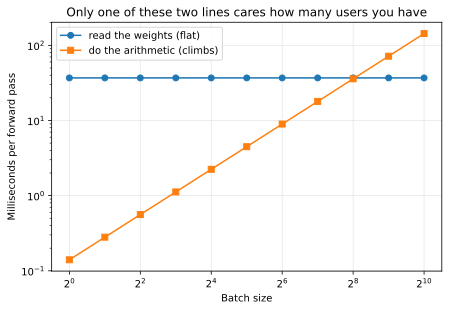

In [5]:
batches = np.array([1,2,4,8,16,32,64,128,256,512,1024])

read    = np.full_like(batches, read_seconds, dtype=float)
compute_t = np.array([compute_seconds(b) for b in batches])

plt.figure(figsize=(7,4.5))
plt.plot(batches, 1000*read,      'o-', label='read the weights (flat)')
plt.plot(batches, 1000*compute_t, 's-', label='do the arithmetic (climbs)')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Batch size'); plt.ylabel('Milliseconds per forward pass')
plt.title('Only one of these two lines cares how many users you have')
plt.legend(); plt.grid(alpha=.3)
plt.show()

In [6]:
i  = np.argmax(compute_t > read)
lo, hi = batches[i-1], batches[i]
print(f'the lines cross between batch {lo} and batch {hi}')
print(f'below that, the GPU waits on memory. above it, it waits on math.')

the lines cross between batch 256 and batch 512
below that, the GPU waits on memory. above it, it waits on math.


### The same fact, without the units

Divide one by the other and the seconds cancel, which leaves two plain
counts you can compare:

$$\text{hardware} = \frac{\text{FLOP/s}}{\text{bytes/s}} \qquad
  \text{workload} = \frac{2NB}{2N} = B$$

The workload ratio *is* the batch size. The 2 and the N cancel. So the whole
question collapses to: is your batch bigger than this number?

In [7]:
ridge = compute / bandwidth
print(f'this hardware: {ridge:.0f} FLOP per byte')
print(f'batch < {ridge:.0f}  ->  memory-bound, the arithmetic units idle')
print(f'batch > {ridge:.0f}  ->  compute-bound, the memory system idles')

this hardware: 263 FLOP per byte
batch < 263  ->  memory-bound, the arithmetic units idle
batch > 263  ->  compute-bound, the memory system idles


That number has a name. It is the **ridge point**, and it is the single most
useful fact about a GPU you are serving from.

It explains continuous batching, which exists to push the batch up towards it.
It explains PagedAttention, which exists because KV memory is what stops you
getting there. It explains quantization, which moves the ridge by shrinking
the numerator of the workload ratio.

The next notebook measures it on your own card instead of a placeholder.

    ./vc info